# Medidas de localización 

Práctica 4 · ENDIREH 2021

**Objetivo:** describir el centro de la distribucion del tiempo sin convivencia con la pareja mediante media, mediana, moda y percentiles; comparar resultados con y sin `factor_expansion`; presentar e interpretar un histograma ponderado.

Ejecuta las celdas en orden con el entorno creado previamente. Las funciones se reutilizan desde `src/statistics/` y `src/visualization/`. Este notebook exporta resultados propios y se puede ejecutar independientemente del de variabilidad.

## 1. Configuración

In [7]:
from pathlib import Path
import sys
from html import escape

RUTA_PROYECTO = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config/rutas.py").is_file()),
    None,
)
if RUTA_PROYECTO is None:
    raise RuntimeError("Abre Jupyter desde la raíz del proyecto o notebooks/.")
if str(RUTA_PROYECTO) not in sys.path:
    sys.path.insert(0, str(RUTA_PROYECTO))

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Markdown
from config.rutas import (
    RUTA_ENDIREH_RENOMBRADO_CSV, RUTA_FIGURAS_PERSONA_1,
    RUTA_LOCALIZACION_CSV, RUTA_HISTOGRAMA_PERSONA_1,
)
from src.statistics.descriptivas import VARIABLE, preparar_base, resumir_por_grupo
from src.visualization.persona_1 import histograma_ponderado, boxplot_ponderado

%matplotlib inline

def mostrar_tabla(tabla):
    """Presenta todas las filas, conservando la precisión completa en los CSV."""
    def formato(v):
        if v is None:
            return "—"
        if isinstance(v, float):
            return f"{v:.2f}"
        if isinstance(v, int):
            return f"{v:,}"
        return escape(str(v))
    encabezado = "".join(f"<th>{escape(c.replace('_', ' '))}</th>" for c in tabla.columns)
    filas = "".join("<tr>" + "".join(f"<td>{formato(v)}</td>" for v in row) + "</tr>" for row in tabla.rows())
    display(HTML(f'<div style="overflow-x:auto"><table><thead><tr>{encabezado}</tr></thead><tbody>{filas}</tbody></table></div>'))

RUTA_FIGURAS_PERSONA_1.mkdir(parents=True, exist_ok=True)


## 2. Variable, universo y cobertura

Analizamos **`anios_sin_convivencia_pareja`**, expresada en años, la cual nos da el tiempo transcurrido desde que se dejo de vivir con la pareja. Es el nombre corregido de `edad_primer_union`; **no mide la edad de la primera union**. La correspondencia esta documentada en el notebook de ajuste. Para esta variable, los cuestionarios compatibles son **A2, B1 y B2**.

Se muestran el total disponible y los grupos del indicador `sufrio_violencia_pareja` (0 y 1).

Para la Practica 4 se recuperaron los codigos validos de 0 a 9 desde la misma fuente, despues de comprobar su correspondencia fila a fila con el CSV limpio. 

**El codigo 0 significa menos de un ano, no ausencia exacta de tiempo.** Para los calculos se conserva la codificacion recibida. La media y el CV describen esa escala de años codificados y tienen una precision limitada para los tiempos inferiores a un año. En A2 puede tratarse de ausencia temporal de la pareja y en B2 de tiempo desde su fallecimiento; no todos los registros representan una ruptura.

In [9]:
if not RUTA_ENDIREH_RENOMBRADO_CSV.is_file():
    raise FileNotFoundError("Ejecuta primero ajuste_columnas_practica_4.ipynb para generar la entrada.")
datos = pl.read_csv(RUTA_ENDIREH_RENOMBRADO_CSV, infer_schema_length=None)
base, cobertura = preparar_base(datos)
mostrar_tabla(cobertura)

grupo,n dataset,n universo a2 b1 b2,n disponibles,n faltantes en universo,porcentaje disponible dataset,porcentaje disponible universo
Total disponible,"110,127","24,560","23,677",883,21.50,96.40
No reportó violencia,"90,821","15,843","15,210",633,16.75,96.00
Reportó violencia,"19,306","8,717","8,467",250,43.86,97.13


## 3. Criterios y formulas

Para valores disponibles $x_i$ y pesos positivos $w_i$, la **media ponderada** es

$$\bar{x}_w=\frac{\sum_i w_i x_i}{\sum_i w_i}.$$

La distribucion acumulada ponderada es $F_w(t)=\sum_i w_i\mathbf{1}(x_i\leq t)/\sum_i w_i$. El cuantil $Q_w(p)$ es el primer valor observado cuya frecuencia acumulada alcanza $p$. La **mediana ponderada** es $Q_w(0.50)$; tambien calculamos P10, Q1, Q3 y P90. La **moda ponderada** es el valor que reune la mayor suma de pesos.

Se usa `inverted_cdf` en ambos casos: pesos unitarios para el calculo sin ponderar y `factor_expansion` para el ponderado. Es una convencion explicita de cuantiles, sin interpolacion; una mediana ordinaria que promedia dos valores centrales puede diferir en muestras de tamaño par. Las funciones validan los valores y pesos y no descartan silenciosamente casos invalidos.

Los factores cambian la contribucion relativa de cada registro. La recuperación de 0 a 9 se realiza antes del análisis; los pesos no compensan la selección por disponibilidad ni las respuestas especiales. La suma de pesos de este subconjunto no se presenta como el total nacional de mujeres.

In [12]:
localizacion = resumir_por_grupo(base, "localizacion")
mostrar_tabla(localizacion.select("grupo", "ponderacion", "n", "media", "mediana", "moda", "p10", "q1", "q3", "p90"))

grupo,ponderacion,n,media,mediana,moda,p10,q1,q3,p90
Total disponible,Sin ponderar,"23,677",10.03,6.00,0,0.00,2.00,15.00,25.00
Total disponible,Factor de expansión,"23,677",9.70,6.00,0,0.00,2.00,15.00,25.00
No reportó violencia,Sin ponderar,"15,210",10.03,6.00,0,0.00,2.00,15.00,26.00
No reportó violencia,Factor de expansión,"15,210",9.77,6.00,0,0.00,2.00,15.00,25.00
Reportó violencia,Sin ponderar,"8,467",10.03,6.00,0,0.00,2.00,15.00,25.00
Reportó violencia,Factor de expansión,"8,467",9.58,6.00,0,0.00,2.00,15.00,24.00


## 4. Interpretacion de las medidas

La unidad de todas las medidas de esta tabla es **años**; `n` indica registros disponibles, sin expandir. La fila ponderada del total es la referencia principal. Las comparaciones por violencia reportada son descriptivas y pertenecen al mismo subconjunto seleccionado.

La media ponderada es 9.70 años codificados y la mediana, 6 años. La media superior a la mediana es consistente con una cola hacia tiempos largos. Los cuartiles delimitan la parte central entre 2 y 15 años; P10 = 0 (0 significa menos de un año) y P90 = 25 años. La moda ponderada es menos de un año (código 0).

Sin ponderar, la media es 10.03 años. El factor cambia la media en -0.33 años. Por grupos, las medias ponderadas son 9.77 años sin violencia reportada y 9.58 con violencia reportada; las medianas son 6 y 6 años, respectivamente. Estas diferencias no demuestran significancia estadística ni un efecto causal. Los resultados se refieren a tiempos disponibles de A2/B1/B2, incluyendo los tiempos recientes recuperados.

## 5. Histograma ponderado

Cada barra agrega intervalos de dos años y representa el porcentaje de la suma de factores **dentro del subconjunto disponible**. Las barras suman 100 %. Se señalan la media y la mediana ponderadas.

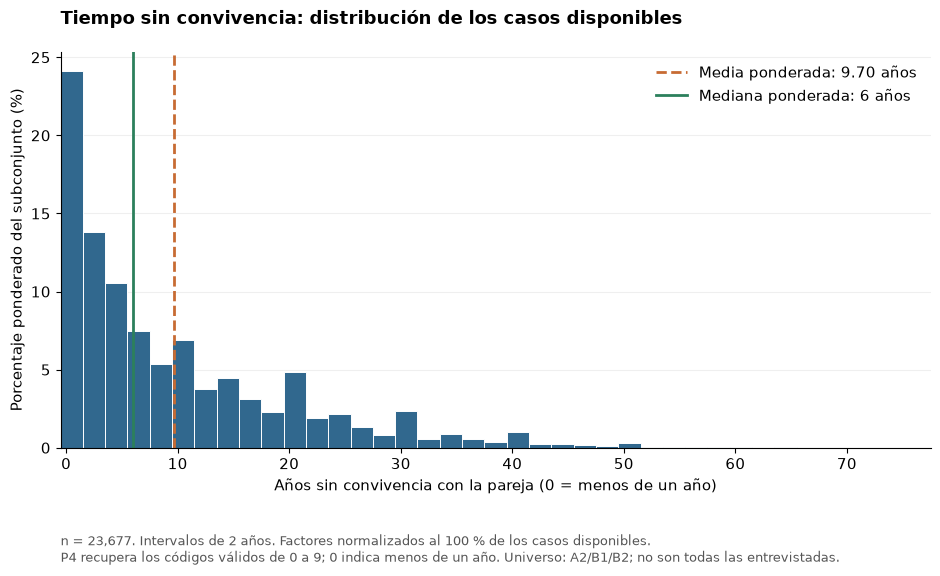

In [5]:
figura = histograma_ponderado(base)
figura.savefig(RUTA_HISTOGRAMA_PERSONA_1, dpi=300, facecolor="white")
plt.show()
plt.close(figura)

El histograma incorpora los codigos validos de 0 a 9 recuperados. Muestra concentracion en tiempos recientes y una cola hacia tiempos largos; la primera barra incluye el código 0 («menos de un año») y 1 año. No equivale a una duración exacta de cero ni permite separar meses. Se refiere a los casos disponibles del universo A2/B1/B2.

## 6. Aportacion y limites

La media y la mediana resumen el centro, pero ocultan diferencias entre trayectorias, la dispersion y la seleccion de registros. El notebook de variabilidad completa esta lectura con CV, IQR y boxplots. El tiempo transcurrido tampoco mide gravedad ni frecuencia de violencia, ni establece que la violencia haya provocado el fin de convivencia.


In [14]:
print(f"Figura exportada: {RUTA_HISTOGRAMA_PERSONA_1.relative_to(RUTA_PROYECTO)}")

Figura exportada: reports/persona_1/figuras/histograma_ponderado.png
